In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import subprocess
import re
import os

# まずは，crime のデータに分類辞書を結合する

crime_dict = pd.read_csv(r"crime_dictionary.csv")

# まずは，各年のcrime.csvを縦結合し，5年分のデータを作る
dfs = {}

for year in range(2020, 2024+1):
    dfs[year] = pd.read_csv(rf"Crimes{year}.csv") 
    # dfs.append(df)

crime = pd.concat(dfs.values(), ignore_index=True)

col = crime.pop("year")
crime.insert(1, "year", col)


# 次に，crime のデータに分類辞書を結合する
crime_dict = pd.read_csv(r"crime_dictionary.csv")

crime_merge = pd.merge(crime, crime_dict, on = "primary_type", how = "left")
col = crime_merge.pop("crime_group1_prime")
crime_merge.insert(2, "crime_group1_prime", col)
crime_merge.rename(columns = {"crime_group1_prime" : "crimetype"}, inplace = True)


# 最後に，年別，コミュニティエリア別の集計表を作る
crime_summary = (
    crime_merge
    .groupby(["year", "community_area", "crimetype"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)


### 次に，ACSのデータをcommunity_areaごとに集計

# データセットの読み込み，リポジトリよりファイルを抽出
# Git管理されている _2020-2024.csv ファイルを取得
files = subprocess.check_output(
    ["git", "ls-files", "*_2020-2024.csv"],
    text=True
).splitlines()

# ACS_ と _2020-2024.csv の間を抽出
acs_list = [
    re.search(r"ACS(.*?)_2020-2024\.csv", f).group(1)
    for f in files
    if re.search(r"ACS(.*?)_2020-2024\.csv", f)
]

acs_summary = None

for dataset in acs_list:

    # 読み込み
    df1 = pd.read_csv(f"ACS{dataset}_2020-2024.csv")
    
    # 後ろ10列を除外
    sum_cols = df1.columns[:-10]

    # グループキーを除外
    sum_cols = [
        col for col in sum_cols
        if col not in ["year", "community_area"]
    ]

    # year × community_areaで集計
    result = (
        df1.groupby(
            ["year", "community_area"],
            as_index=False
        )[sum_cols]
        .sum()
    )


    # 横結合
    if acs_summary is None:
        acs_summary = result
    else:
        acs_summary = pd.merge(
            acs_summary,
            result,
            on=["year", "community_area"],
            how="outer"
        )


## 最後に，headerにcrime_summaryとacs_summaryを横結合
header = pd.read_csv("header.csv")

chicago = pd.merge(header, crime_summary, on = ["year", "community_area"],
                   how = "left")

chicago = pd.merge(chicago, acs_summary, 
                   on = ["year", "community_area"],
                   how = "left")

# chicago.to_csv("chicago.csv", index = False)




In [7]:
col = list(chicago.columns) 
exclude = ['community', 'commarea_km2']
int_col = [c for c in col if c not in exclude]
chicago[int_col] = chicago[int_col].astype(int)
chicago["community_area"] = chicago["community_area"].astype("category")
print(chicago.dtypes)

year                 int64
community_area    category
comm_pop             int64
community              str
commarea_km2       float64
other1               int64
property1            int64
public_order1        int64
violent1             int64
malepop              int64
male15_19pop         int64
male15_24pop         int64
male15_29pop         int64
allwhitepop          int64
allblackpop          int64
dtype: object


In [8]:
chicago.columns

Index(['year', 'community_area', 'comm_pop', 'community', 'commarea_km2',
       'other1', 'property1', 'public_order1', 'violent1', 'malepop',
       'male15_19pop', 'male15_24pop', 'male15_29pop', 'allwhitepop',
       'allblackpop'],
      dtype='str')

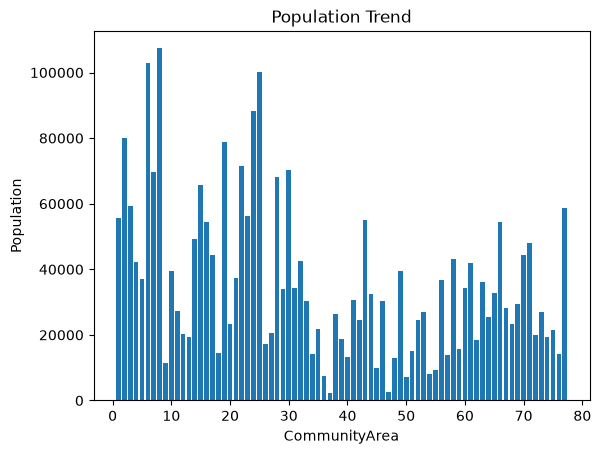

In [9]:
plt.bar(chicago["community_area"], chicago["comm_pop"])

plt.xlabel("CommunityArea")
plt.ylabel("Population")
plt.title("Population Trend")

plt.show()

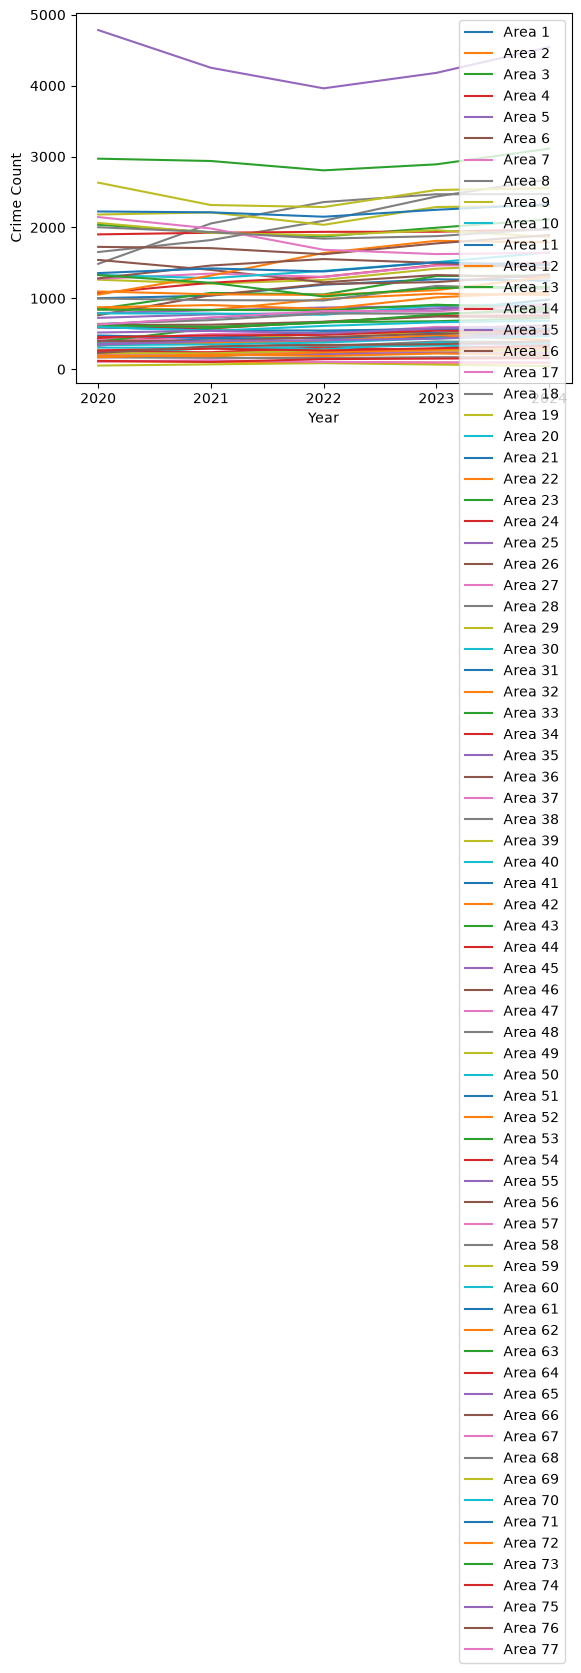

In [13]:
for area in chicago["community_area"].unique():
    temp = chicago[chicago["community_area"] == area]
    
    plt.plot(
        temp["year"],
        temp["violent1"],
        label=f"Area {area}"
    )

plt.xlabel("Year")
plt.ylabel("Crime Count")
plt.xticks(chicago["year"].unique())
plt.legend()
plt.show()

利用可能な変数:
['year', 'community_area', 'comm_pop', 'community', 'commarea_km2', 'other1', 'property1', 'public_order1', 'violent1', 'malepop', 'male15_19pop', 'male15_24pop', 'male15_29pop', 'allwhitepop', 'allblackpop']


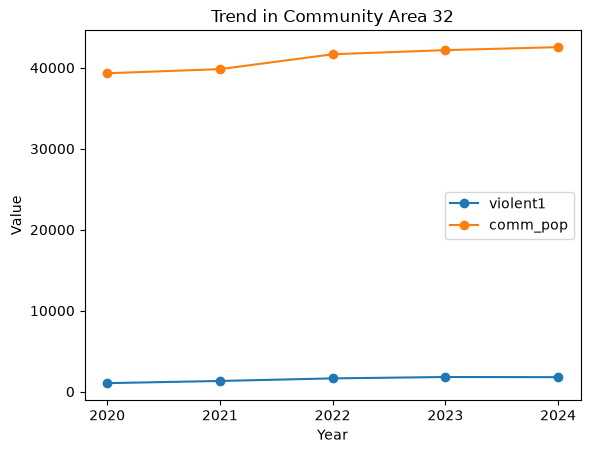

In [15]:
# community_areaを指定
area = int(input("Community Areaを入力してください: "))

# 表示したい変数を入力（最大5個）
print("利用可能な変数:")
print(list(chicago.columns))

variables = input(
    "表示する変数名をカンマ区切りで入力してください（最大5個）: "
).split(",")

# 空白除去
variables = [v.strip() for v in variables]

# 5個以内か確認
if len(variables) > 5:
    print("変数は5個までです")
else:
    # 指定したcommunity_areaのみ抽出
    data = chicago[
        chicago["community_area"] == area
    ].sort_values("year")

    # データが存在するか確認
    if data.empty:
        print("該当するCommunity Areaがありません")
    else:
        # グラフ描画
        for var in variables:
            plt.plot(
                data["year"],
                data[var],
                marker="o",
                label=var
            )

        plt.xlabel("Year")
        plt.ylabel("Value")
        plt.title(f"Trend in Community Area {area}")

        # 年を整数表示
        plt.xticks(data["year"])

        # 凡例
        plt.legend()

        plt.show()

In [21]:
# 人口系変数
population_vars = [
    "comm_pop",
    "malepop",
    "male15_19pop",
    "male15_24pop",
    "male15_29pop",
    "allwhitepop",
    "allblackpop"
]

# 犯罪系変数
crime_vars = [
    "other1",
    "property1",
    "public_order1",
    "violent1"
]


# yearとcommunity_area以外の変数一覧
available_vars = [
    col for col in chicago.columns
    if col not in ["year", "community_area", "community", "commarea_km2"]
]


# 変数一覧を番号付きで作成
variable_text = "\n".join(
    [f"{i}: {var}" for i, var in enumerate(available_vars, start=1)]
)


# Community Area入力
print("Community Areaは1〜77の範囲で入力してください")
area = int(input("Community Areaを入力してください: "))


# # 利用可能変数を表示
# print("\n利用可能な変数:")
# print(", ".join(available_vars))


# # 表示変数入力
# variables = input(
#     "\n表示する変数を入力してください（カンマ区切り、最大5個）: "
# ).split(",")


# input画面に表示
selected_numbers = input(
    "\n利用可能な変数:\n"
    f"{variable_text}\n\n"
    "表示する変数の番号を入力してください（カンマ区切り、最大5個）: "
).split(",")



# 空白削除
selected_numbers = [v.strip() for v in selected_numbers]

# 番号 → 変数名へ変換
variables = [
    available_vars[i-1]
    for i in selected_numbers
]


# 入力チェック
if len(variables) > 5:
    print("変数は最大5個までです")

elif not all(v in available_vars for v in variables):
    print("存在しない変数が含まれています")

else:

    # Community Areaで抽出
    data = chicago[
        chicago["community_area"] == area
    ].sort_values("year")


    if data.empty:
        print("該当するCommunity Areaがありません")

    else:

        # グラフ作成
        fig, ax1 = plt.subplots(figsize=(10, 6))


        # 左軸（人口系）
        pop_selected = [
            v for v in variables
            if v in population_vars
        ]

        for var in pop_selected:
            ax1.plot(
                data["year"],
                data[var],
                marker="o",
                label=var
            )

        ax1.set_xlabel("Year")
        ax1.set_ylabel("Population")


        # 右軸（犯罪系）
        crime_selected = [
            v for v in variables
            if v in crime_vars
        ]

        if crime_selected:

            ax2 = ax1.twinx()

            for var in crime_selected:
                ax2.plot(
                    data["year"],
                    data[var],
                    marker="x",
                    linestyle="--",
                    label=var
                )

            ax2.set_ylabel("Crime Count")


        # 凡例を統合
        lines1, labels1 = ax1.get_legend_handles_labels()

        if crime_selected:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(
                lines1 + lines2,
                labels1 + labels2,
                loc="upper left"
            )
        else:
            ax1.legend(loc="upper left")


        # 年を整数表示
        ax1.set_xticks(data["year"])


        plt.title(
            f"Trend in Community Area {area}"
        )

        plt.show()

Community Areaは1〜77の範囲で入力してください


TypeError: unsupported operand type(s) for -: 'str' and 'int'